### Exercise 4: visualization MCP server

The Streamable HTTP server runs at `http://127.0.0.1:8003/mcp`.

In [1]:
import base64
import io
import socket
import threading
import time
from pathlib import Path
from typing import Annotated

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from fastmcp import FastMCP
from IPython.display import Image, display
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client

### Define the visualization server and tool

In [3]:
mcp = FastMCP("Visualization server")


@mcp.tool(
    description=(
        "Create a line plot from one or more numeric data series and return "
        "the PNG image encoded as base64."
    )
)
def line_plot(
    data: Annotated[
        list[list[float]],
        "One or more lists of numbers. Each inner list is plotted as one line.",
    ],
    title: Annotated[str | None, "Optional plot title."] = None,
    x_label: Annotated[str | None, "Optional x-axis label."] = None,
    y_label: Annotated[str | None, "Optional y-axis label."] = None,
    legend: Annotated[bool, "Whether to display a legend."] = False,
) -> str:
    if not data:
        raise ValueError("data must contain at least one numeric series")
    if any(not series for series in data):
        raise ValueError("each data series must contain at least one number")

    figure, axis = plt.subplots(figsize=(8, 5))

    for index, series in enumerate(data, start=1):
        axis.plot(series, marker="*", label=f"Series {index}")

    if title:
        axis.set_title(title)
    if x_label:
        axis.set_xlabel(x_label)
    if y_label:
        axis.set_ylabel(y_label)
    if legend:
        axis.legend()

    axis.grid(True, alpha=0.3)
    figure.tight_layout()

    image_buffer = io.BytesIO()
    figure.savefig(image_buffer, format="png", dpi=150)
    plt.close(figure)
    image_buffer.seek(0)

    return base64.b64encode(image_buffer.read()).decode("ascii")

### Start the Streamable HTTP server

In [4]:
HOST = "127.0.0.1"
PORT = 8003
MCP_URL = f"http://{HOST}:{PORT}/mcp"


def port_is_open(host: str, port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as connection:
        connection.settimeout(0.2)
        return connection.connect_ex((host, port)) == 0


if port_is_open(HOST, PORT):
    print(f"A server is already running at {MCP_URL}")
else:
    server_thread = threading.Thread(
        target=mcp.run,
        kwargs={
            "transport": "streamable-http",
            "host": HOST,
            "port": PORT,
            "show_banner": False,
        },
        daemon=True,
        name="exercise4-visualization-server",
    )
    server_thread.start()

    for _ in range(50):
        if port_is_open(HOST, PORT):
            break
        time.sleep(0.1)
    else:
        raise RuntimeError("The MCP server did not start on port 8003.")

    print(f"Visualization MCP server started at {MCP_URL}")

[06/12/26 21:30:20] INFO     Starting MCP server 'Visualization server' with transport               ]8;id=67733;file:///Users/weronika/Desktop/AGH_ISSI/IPUM/Lab6/.venv/lib/python3.11/site-packages/fastmcp/server/server.py\server.py]8;;\:]8;id=114819;file:///Users/weronika/Desktop/AGH_ISSI/IPUM/Lab6/.venv/lib/python3.11/site-packages/fastmcp/server/server.py#2585\2585]8;;\
                             'streamable-http' on http://127.0.0.1:8003/mcp                                        

INFO:     Started server process [3648]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8003 (Press CTRL+C to quit)


Visualization MCP server started at http://127.0.0.1:8003/mcp


### Test the `line_plot` tool

In [5]:
sample_arguments = {
    "data": [
        [1, 3, 2, 5, 4, 7],
        [2, 2, 4, 3, 6, 5],
        [0, 1, 1, 2, 3, 5],
    ],
    "title": "Sample line plot",
    "x_label": "Observation",
    "y_label": "Value",
    "legend": True,
}


async with streamable_http_client(MCP_URL) as streams:
    read_stream, write_stream, _ = streams
    async with ClientSession(read_stream, write_stream) as session:
        await session.initialize()

        tools_response = await session.list_tools()
        tool_names = [tool.name for tool in tools_response.tools]
        print("Available tools:", tool_names)

        plot_response = await session.call_tool(
            "line_plot",
            arguments=sample_arguments,
        )
        image_base64 = plot_response.structuredContent["result"]

print("Base64 characters returned:", len(image_base64))

INFO:     127.0.0.1:50358 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50359 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:50360 - "GET /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50361 - "POST /mcp HTTP/1.1" 200 OK
Available tools: ['line_plot']
INFO:     127.0.0.1:50362 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50363 - "DELETE /mcp HTTP/1.1" 200 OK
Base64 characters returned: 100340


### Decode, validate and save the image

Saved 75,253 PNG bytes to: /Users/weronika/Desktop/AGH_ISSI/IPUM/Lab6/exercise4_line_plot.png


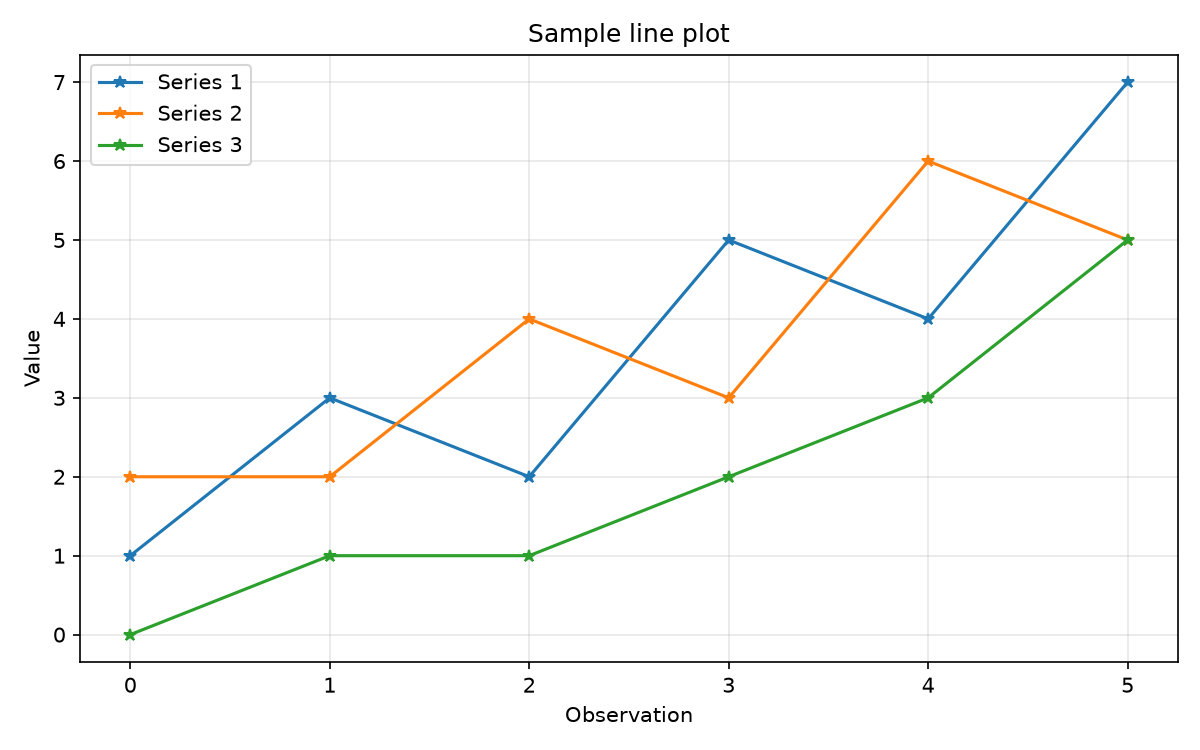

In [6]:
image_bytes = base64.b64decode(image_base64)
output_path = Path("exercise4_line_plot.png")
output_path.write_bytes(image_bytes)

assert tool_names == ["line_plot"]
assert image_bytes.startswith(b"\x89PNG\r\n\x1a\n")
assert len(image_bytes) > 1000

print(f"Saved {len(image_bytes):,} PNG bytes to: {output_path.resolve()}")
display(Image(filename=str(output_path)))

### Results and conclusions

The tool accepted three lists of numbers together with a title, axis labels, and the legend option. It created the chart with Matplotlib and returned the PNG file as a base64 string. The client decoded the string, checked the PNG header, and saved the result as `exercise4_line_plot.png`. The test confirmed that the server exposed the correct tool and produced a valid image.